# Preparation

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Global Threshold

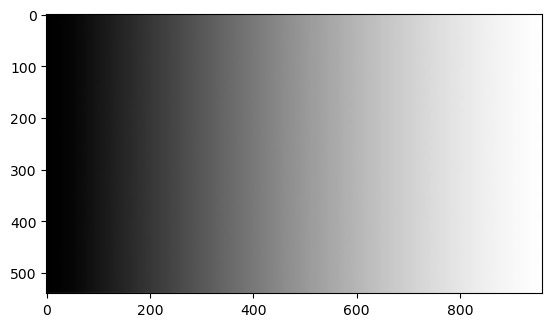

In [2]:
img = cv2.imread('../assets/gradient.jpg')

if img is None:
    raise Exception('Image is not found!')

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img)
plt.show()

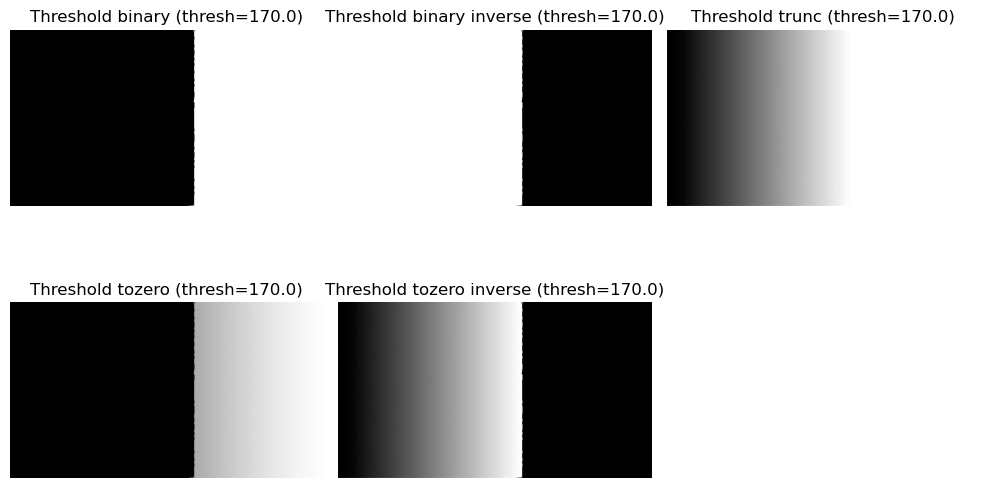

In [3]:
threshold_steps = [
    {
        'name': 'Threshold binary',
        'type': cv2.THRESH_BINARY
    },
    {
        'name': 'Threshold binary inverse',
        'type': cv2.THRESH_BINARY_INV
    },
    {
        'name': 'Threshold trunc',
        'type': cv2.THRESH_TRUNC
    },
    {
        'name': 'Threshold tozero',
        'type': cv2.THRESH_TOZERO
    },
    {
        'name': 'Threshold tozero inverse',
        'type': cv2.THRESH_TOZERO_INV
    },
]

plt.figure(figsize=(10, 6))

for i, step in enumerate(threshold_steps):
    ret, thresh_img = cv2.threshold(
        img_gray, 
        thresh=170, 
        maxval=255, 
        type=step['type']
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(thresh_img, cmap='gray')
    plt.title(f'{step['name']} (thresh={ret})')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Otsu Threshold

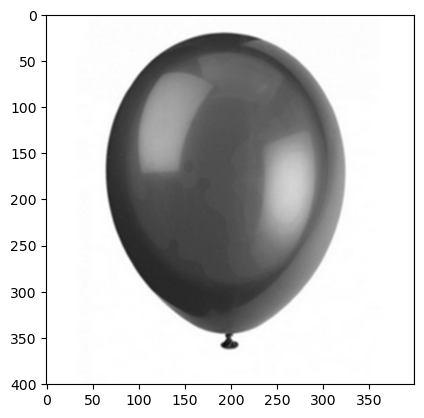

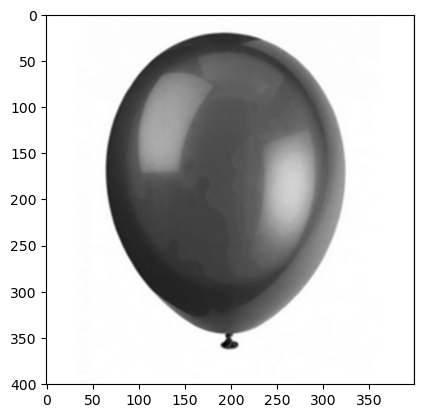

In [4]:
img_balloon = cv2.imread('../assets/balloon.png')

if img_balloon is None:
    raise Exception('Image is not found!')


img_balloon_gray = cv2.cvtColor(img_balloon, cv2.COLOR_BGR2GRAY)

plt.imshow(img_balloon)
plt.show()

plt.imshow(img_balloon_gray, cmap='gray')
plt.show()

Otsu optimal threshold: 172


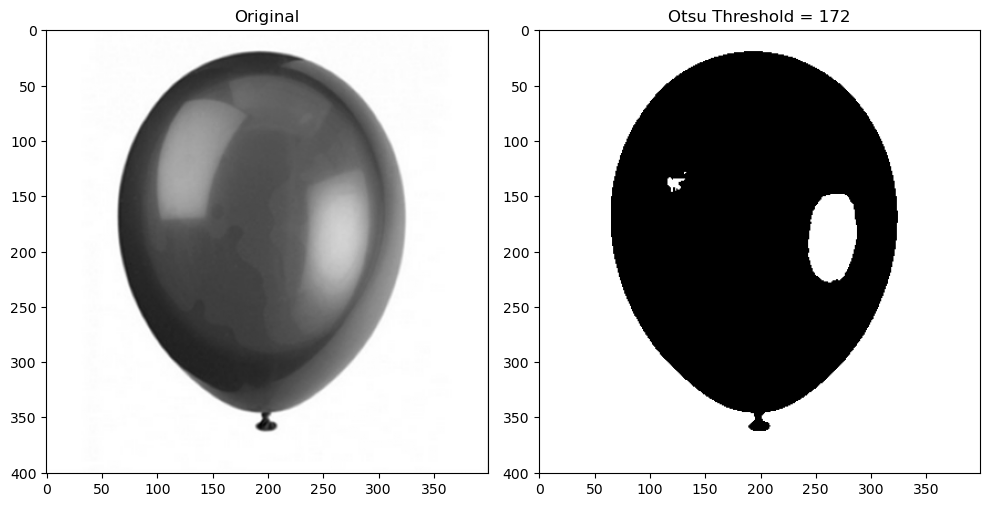

In [5]:
# iterating pixel by pixel
height, width = img_balloon_gray.shape

thresh = 170
max_val = 255


# 1. Compute histogram
hist, bins = np.histogram(img_balloon_gray.ravel(), bins=256, range=(0, 256))

# 2. Normalize histogram (to probabilities)
hist = hist.astype(np.float32)
hist /= hist.sum()

# 3. Compute cumulative sums and means
cum_sum = np.cumsum(hist)
cum_mean = np.cumsum(hist * np.arange(256))
global_mean = cum_mean[-1]

# 4. Compute between-class variance for all thresholds
var_between = (global_mean * cum_sum - cum_mean)**2 / (cum_sum * (1 - cum_sum) + 1e-10)

# 5. Find threshold that maximizes variance
otsu_thresh = np.argmax(var_between)

print("Otsu optimal threshold:", otsu_thresh)

# 6. Apply the threshold manually (Binary)
img_otsu = np.where(img_balloon_gray > otsu_thresh, 255, 0).astype(np.uint8)

# 7. Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_balloon_gray, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(img_otsu, cmap='gray')
plt.title(f'Otsu Threshold = {otsu_thresh}')

plt.tight_layout()
plt.show()

# Histogram

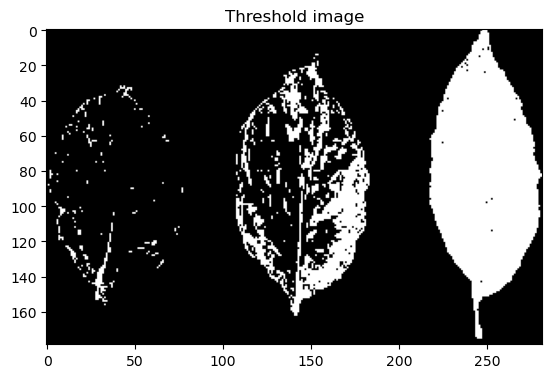

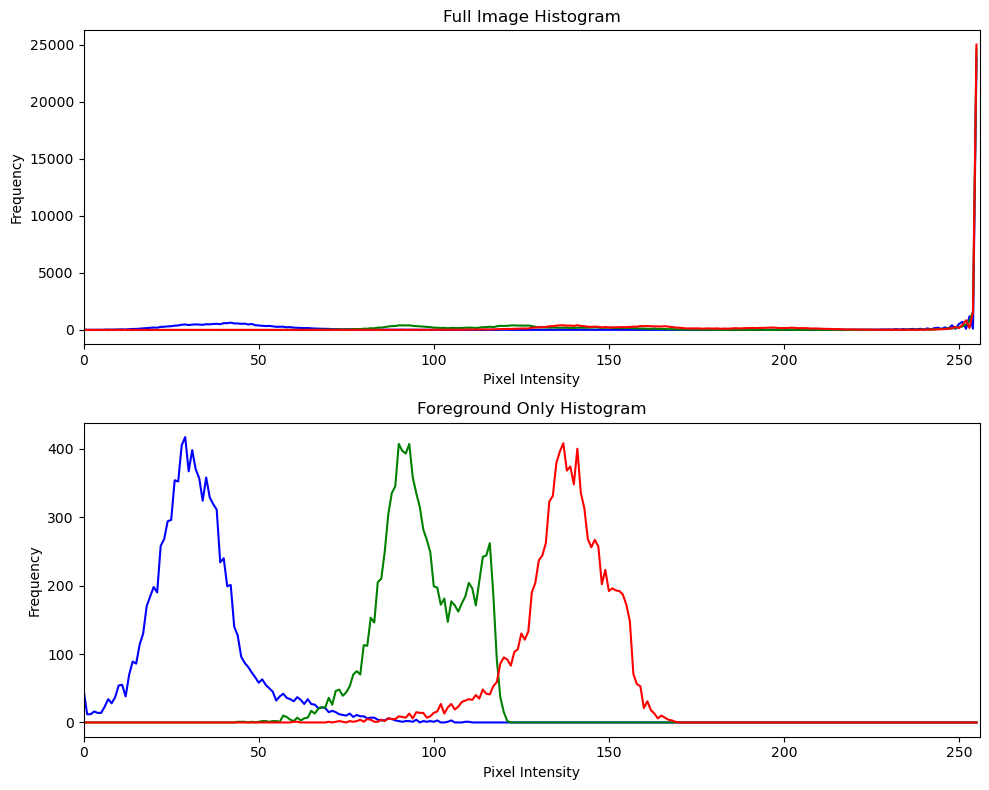

In [12]:
img_tobacco = cv2.imread('../assets/tobacco.jpeg')

if img_tobacco is None:
    raise Exception('Image is not found!')

# Convert to grayscale for mask generation
img_tobacco_gray = cv2.cvtColor(img_tobacco, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(
    img_tobacco_gray, 
    thresh=120,
    maxval=255,
    type=cv2.THRESH_BINARY_INV
)

plt.title('Threshold image')
plt.imshow(mask, cmap='gray')
plt.show()

colors = ('b', 'g', 'r')

# Create figure with 2 rows: Full Image vs Foreground
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# --------------- FULL IMAGE HISTOGRAM ----------------
for i, color in enumerate(colors):
    hist_full = cv2.calcHist(
        [img_tobacco], [i], None, [256], [0, 256]
    )
    axes[0].plot(hist_full, color=color)
axes[0].set_title('Full Image Histogram')
axes[0].set_xlim([0, 256])
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')

# --------------- FOREGROUND HISTOGRAM ----------------
for i, color in enumerate(colors):
    hist_foreground = cv2.calcHist(
        [img_tobacco], [i], mask, [256], [0, 256]
    )
    axes[1].plot(hist_foreground, color=color)
axes[1].set_title('Foreground Only Histogram')
axes[1].set_xlim([0, 256])
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()